## Install or Import Packages

In [1]:
# Install grad-cam package (only for this notebook)
%pip install grad-cam

Note: you may need to restart the kernel to use updated packages.


In [2]:
%cd ..

/common/wut4/workspace/OCT


In [3]:
import os, torch
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import pandas as pd

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

from model import ResNetClassifier
from dataloader import data_collector, data_split, get_data_transforms

In [4]:
input_size = '225'

In [5]:
df = pd.read_csv(f'./grafted/{input_size}/grafted_result_{input_size}.csv')

In [6]:
df['group'] = df['path'].apply(lambda x: x.split('/')[4])
df['ID'] = df['path'].apply(lambda x: x.split('/')[5].split('_')[0])
df['image'] = df['path'].apply(lambda x: int(x.split('/')[-1].split('_')[-1].split('.')[0]))

In [7]:
df.head()

,Unnamed: 0,path,pred,group,ID,image
0,0,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,2,400K P60,G401,1
1,1,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,2,400K P60,G401,2
2,2,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,2,400K P60,G401,3
3,3,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,2,400K P60,G401,4
4,4,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,2,400K P60,G401,5


In [11]:
def generate_cmap(timestamp='P60'):
    from matplotlib import cm
    from matplotlib.colors import ListedColormap
    
    top = cm.get_cmap('Greens_r', 4) # r means reversed version
    bottom = cm.get_cmap('Reds', 4)# combine it all
    
    if timestamp == 'P60':
        newcolors = np.vstack((top(np.linspace(0, 1, 4))[1:],
                               bottom(np.linspace(0, 1, 4)[2:])))
    elif timestamp == 'P90':
        newcolors = np.vstack((top(np.linspace(0, 1, 4)),
                               bottom(np.linspace(0, 1, 4)[2:3])))
        
    red_green = ListedColormap(newcolors, name='RedGreen')
    return red_green

/tmp/ipykernel_1608388/2066360694.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  top = cm.get_cmap('Greens_r', 4) # r means reversed version
/tmp/ipykernel_1608388/2066360694.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bottom = cm.get_cmap('Reds', 4)# combine it all
/tmp/ipykernel_1608388/2066360694.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  top = cm.get_cmap('Greens_r', 4) # r means reversed version
/tmp/ipykernel_1608388/2066360694.py:4: MatplotlibDepre

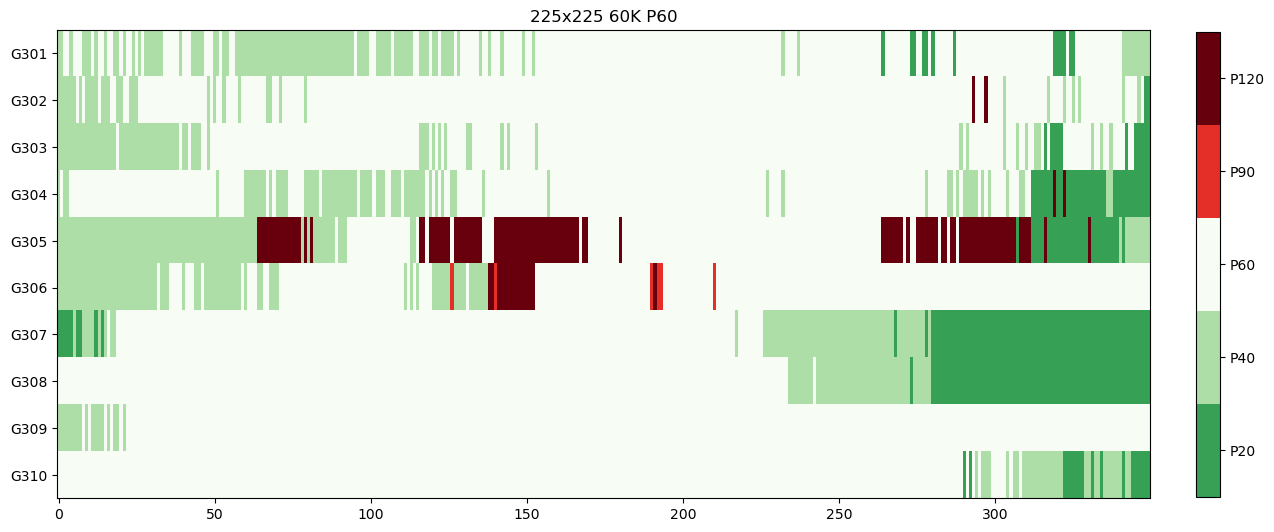

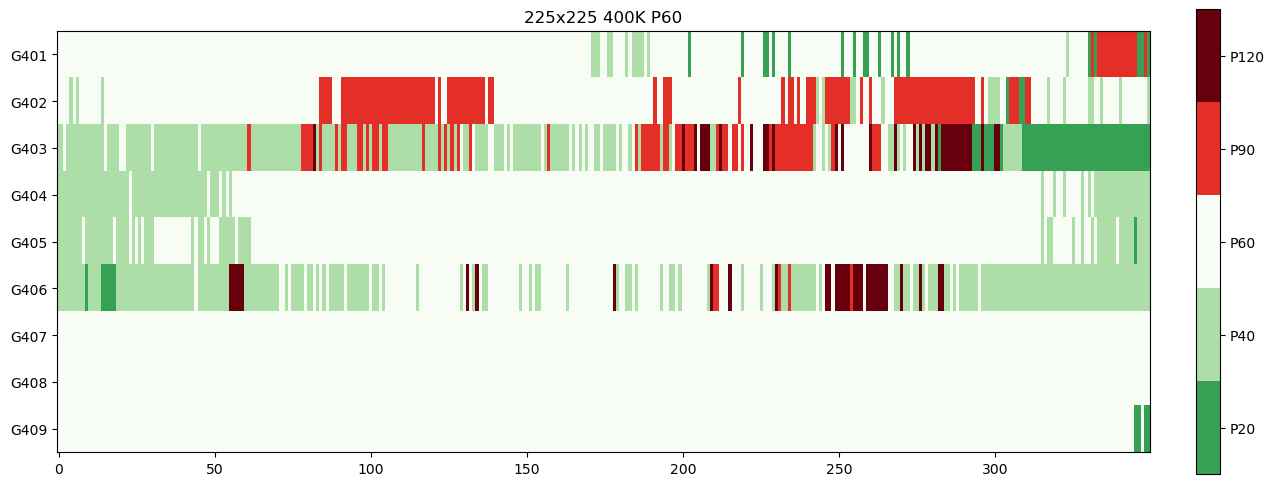

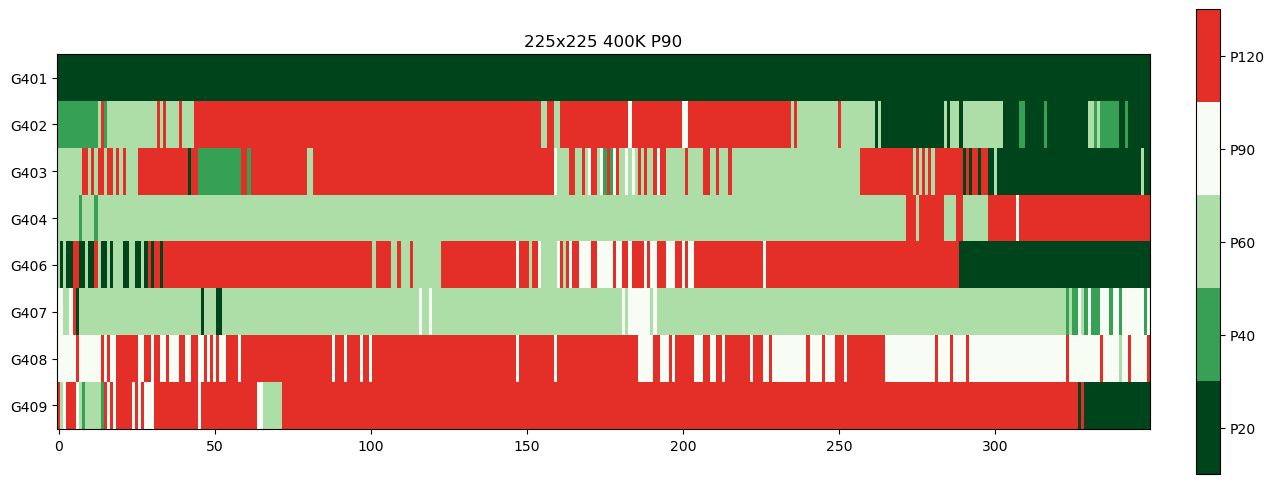

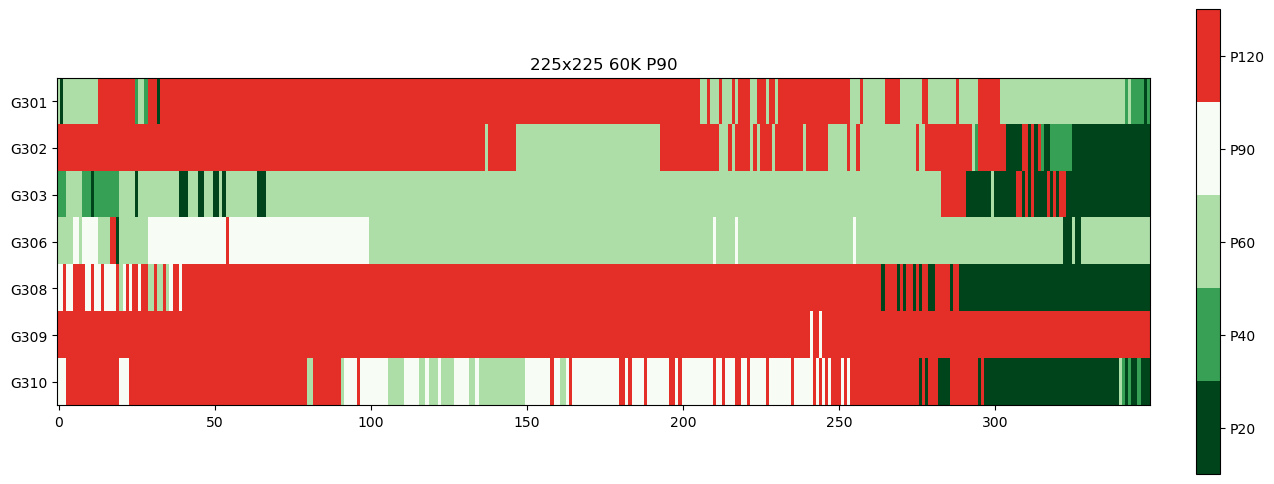

In [12]:
for group in set(list(df['group'])):
    sub_df = df[df['group'] == group]
    ID_list = sorted(list(set(list(sub_df['ID']))))
    n_ID = len(ID_list)

    pred = np.zeros((350, n_ID))
    
    for idx, ID in enumerate(ID_list):
        single_df = sub_df[sub_df['ID'] == ID].sort_values(by='image')
        pred[:, idx] = single_df['pred']

    if group.split(' ')[-1] == 'P60':
        swift = 2
    elif group.split(' ')[-1] == 'P90':
        swift = 3

    red_green = generate_cmap(group.split(' ')[-1])
        
    pred = pred - swift

    plt.figure(figsize=(15, n_ID))
    plt.imshow(pred.T, aspect=15, interpolation="none",cmap=red_green, vmin=np.min(pred) - 0.5, 
                      vmax=np.max(pred) + 0.5)
    plt.yticks(range(n_ID), ID_list)
    plt.title(f"{input_size}x{input_size} {group}")
    
    cbar = plt.colorbar(fraction=0.02, pad=0.04)
    cbar.set_ticks(np.arange(5) - swift)
    cbar.set_ticklabels(['P20', 'P40', 'P60', 'P90', 'P120'])
    plt.savefig(f"./grafted/{input_size}/grafted_{group.replace(' ', '_')}.png")

## Load Model

In [13]:
# 1000x1000
# save_dir = os.path.join('results', '20240321-194738')
# input_shape = 1000
# 225x225
save_dir = os.path.join('results', '20240321-195954')
input_shape = 225

In [14]:
model = ResNetClassifier(num_classes=5)
model = model.load_from_checkpoint(os.path.join(save_dir, 'bestmodel.ckpt'), map_location=torch.device('cpu'))
model.eval()

ResNetClassifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [15]:
# target layer for ResNet 18
target_layers = [model.resnet.layer4[-1]]

In [16]:
cam = GradCAM(model=model, target_layers=target_layers)

## Load Data

In [17]:
ID = 'G401'
group = '400K P90'
idx = 150

In [26]:
def run_grad_cam(df, input_shape, cam, group, ID, idx):
    sub_df = df[(df['group'] == group) & (df['ID'] == ID)]
    img_path = sub_df['path'].values[idx]
    
    data_transforms = get_data_transforms(input_shape=(input_shape, input_shape))['val']
    
    image = Image.open(img_path)
    X = data_transforms(image).unsqueeze(0)
    
    output = model(X)
    pred = np.argmax(output.detach().numpy())
    print(f"Prediction: {pred}, output: {output}")
    
    grayscal_cam = cam(input_tensor=X, targets=None)
    
    visualization = show_cam_on_image(np.transpose(X[0].numpy(), (1, 2, 0)), grayscal_cam[0], use_rgb=True)
    plt.imshow(visualization)
    
    plt.imsave(f"grafted/{str(input_shape)}/{ID}_{group.replace(' ', '_')}_{str(idx)}_gradcam.png", visualization)
    plt.imsave(f"grafted/{str(input_shape)}/{ID}_{group.replace(' ', '_')}_{str(idx)}.png", X.numpy()[0, :, :, :].transpose(1, 2, 0))

Prediction: 0, output: tensor([[ 9.2994,  0.3820, -2.0135, -6.7162, -6.2373]],
       grad_fn=<AddmmBackward0>)
Prediction: 2, output: tensor([[-2.9462, -1.3344,  6.3911, -4.9001, -6.6361]],
       grad_fn=<AddmmBackward0>)
Prediction: 4, output: tensor([[ -8.7816,  -8.4809, -11.8476,   3.0754,  16.4378]],
       grad_fn=<AddmmBackward0>)


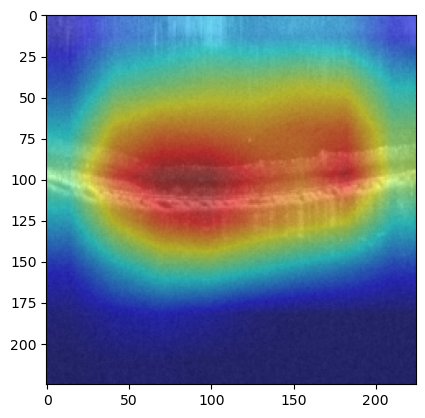

In [29]:
group = '400K P90'
idx = 150

run_grad_cam(df, input_shape, cam, group, 'G401', idx)
run_grad_cam(df, input_shape, cam, group, 'G404', idx)
run_grad_cam(df, input_shape, cam, group, 'G409', idx)

Prediction: 3, output: tensor([[-6.6240, -1.9666,  1.3380,  3.9044, -4.5929]],
       grad_fn=<AddmmBackward0>)
Prediction: 2, output: tensor([[-3.5247, -1.5802,  2.6673, -3.9673, -3.4979]],
       grad_fn=<AddmmBackward0>)


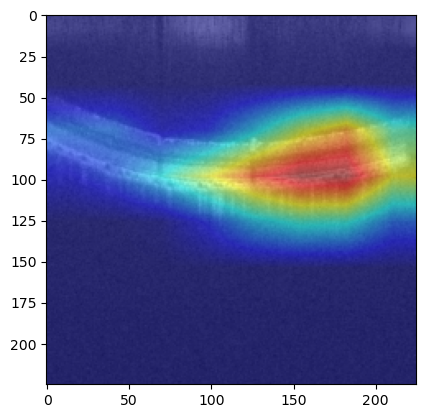

In [30]:
group = '400K P60'

run_grad_cam(df, input_shape, cam, group, 'G402', 100)
run_grad_cam(df, input_shape, cam, group, 'G404', 150)


Prediction: 4, output: tensor([[-3.1185, -3.3828, -7.0748, -2.6683,  8.5811]],
       grad_fn=<AddmmBackward0>)
Prediction: 2, output: tensor([[-5.6788, -4.3516,  7.4175,  1.8644, -9.5666]],
       grad_fn=<AddmmBackward0>)


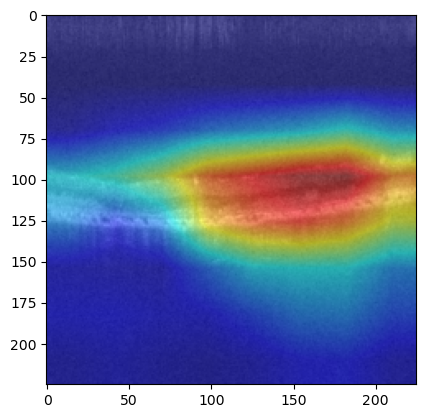

In [31]:
group = '60K P90'

run_grad_cam(df, input_shape, cam, group, 'G301', 150)
run_grad_cam(df, input_shape, cam, group, 'G306', 150)


Prediction: 2, output: tensor([[-5.0350,  3.8701,  5.7950, -5.9998, -9.6748]],
       grad_fn=<AddmmBackward0>)
Prediction: 4, output: tensor([[-3.9715, -2.6196, -1.8649, -2.3848,  1.8682]],
       grad_fn=<AddmmBackward0>)


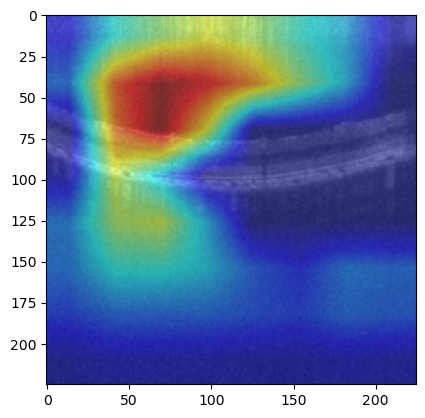

In [32]:
group = '60K P60'

run_grad_cam(df, input_shape, cam, group, 'G302', 150)
run_grad_cam(df, input_shape, cam, group, 'G305', 150)